In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import glob
import pandas as pd

# Read and combine all CSV files into one DataFrame.
test_results = pd.read_csv("/kaggle/input/datasets/smmehedizaman/glenn-model-labels/glenn_model_labels.csv")

# --- Step 2: Load the guest_pairs CSV ---
guest_pairs = pd.read_csv("/kaggle/input/datasets/smmehedizaman/glenn-guest-pairs/glenn_guest_pairs.csv")

# --- Step 3: Clean the columns in the combined DataFrame ---
# Here, we strip quotation marks from the 'Anderson' and 'Guest' columns.
test_results['Glenn'] = test_results['speaker1'].str.strip('"')
test_results['Guest'] = test_results['speaker2'].str.strip('"')

# --- Step 4: Merge the data ---
# We merge on the 'Anderson' and 'Guest' columns, and bring in the 'Date' column from guest_pairs.
merged_df = pd.merge(
    test_results,
    guest_pairs[['Date', 'Glenn', 'Guest']],
    on=['Glenn', 'Guest'],
    how='left'
)

# --- Step 5: Save the merged DataFrame to a CSV file ---
output_path = 'merged_test_results_with_date.csv'
merged_df.to_csv(output_path, index=False)
print("Merged file saved as 'merged_test_results_with_date.csv'")

# Optional: Display the shape and a sample of the merged DataFrame.
print(f"Combined test_results has {test_results.shape[0]} rows and {test_results.shape[1]} columns.")
print(f"Merged DataFrame has {merged_df.shape[0]} rows and {merged_df.shape[1]} columns.")
print(merged_df.head())

Merged file saved as 'merged_test_results_with_date.csv'
Combined test_results has 108383 rows and 5 columns.
Merged DataFrame has 110653 rows and 6 columns.
                                            speaker1  \
0  We got a great show for you today. We... We ta...   
1                              people to watch good.   
2  Yeah. We have a couple that we just like are y...   
3  Yeah, you know, when I think of you and your s...   
4                   called Studez America available.   

                                            speaker2   model_label  \
0  Anything else on Blaze TV when you're doing yo...    neutrality   
1  Really? Yeah, because I mean the place TV has ...     agreement   
2                You can't do that thing. lame legs?  disagreement   
3                                    Yeah. get that.     agreement   
4       What? every week right here on this network.    neutrality   

                                               Glenn  \
0  We got a great show for y

In [3]:
merged_df

,speaker1,speaker2,model_label,Glenn,Guest,Date
0,We got a great show for you today. We... We ta...,Anything else on Blaze TV when you're doing yo...,neutrality,We got a great show for you today. We... We ta...,Anything else on Blaze TV when you're doing yo...,2024-04-23
1,people to watch good.,"Really? Yeah, because I mean the place TV has ...",agreement,people to watch good.,"Really? Yeah, because I mean the place TV has ...",2024-04-23
2,Yeah. We have a couple that we just like are y...,You can't do that thing. lame legs?,disagreement,Yeah. We have a couple that we just like are y...,You can't do that thing. lame legs?,2024-04-23
3,"Yeah, you know, when I think of you and your s...",Yeah. get that.,agreement,"Yeah, you know, when I think of you and your s...",Yeah. get that.,2024-04-23
4,called Studez America available.,What? every week right here on this network.,neutrality,called Studez America available.,What? every week right here on this network.,2024-04-23
...,...,...,...,...,...,...
110648,It's not something I wouldn't wish it on my yo...,That's something I wouldn't wish to- My plan w...,agreement,It's not something I wouldn't wish it on my yo...,That's something I wouldn't wish to- My plan w...,2022-10-27
110649,do,Yeah. Yeah. Right.,neutrality,do,Yeah. Yeah. Right.,2022-10-27
110650,"So Good, just do the next rape thumb. Thanks.","Only God knows where this goes, only God knows.",neutrality,"So Good, just do the next rape thumb. Thanks.","Only God knows where this goes, only God knows.",2022-10-27
110651,"Exactly. Thank you so much, Carrie. Best of luck.","Thank you, Glenn.",neutrality,"Exactly. Thank you so much, Carrie. Best of luck.","Thank you, Glenn.",2022-10-27


In [4]:
# Define the valid labels
valid_labels = ['disagreement', 'neutrality', 'agreement']

# Filter the DataFrame to include only rows with valid labels
merged_df = merged_df[merged_df['model_label'].isin(valid_labels)]

In [5]:
merged_df

,speaker1,speaker2,model_label,Glenn,Guest,Date
0,We got a great show for you today. We... We ta...,Anything else on Blaze TV when you're doing yo...,neutrality,We got a great show for you today. We... We ta...,Anything else on Blaze TV when you're doing yo...,2024-04-23
1,people to watch good.,"Really? Yeah, because I mean the place TV has ...",agreement,people to watch good.,"Really? Yeah, because I mean the place TV has ...",2024-04-23
2,Yeah. We have a couple that we just like are y...,You can't do that thing. lame legs?,disagreement,Yeah. We have a couple that we just like are y...,You can't do that thing. lame legs?,2024-04-23
3,"Yeah, you know, when I think of you and your s...",Yeah. get that.,agreement,"Yeah, you know, when I think of you and your s...",Yeah. get that.,2024-04-23
4,called Studez America available.,What? every week right here on this network.,neutrality,called Studez America available.,What? every week right here on this network.,2024-04-23
...,...,...,...,...,...,...
110648,It's not something I wouldn't wish it on my yo...,That's something I wouldn't wish to- My plan w...,agreement,It's not something I wouldn't wish it on my yo...,That's something I wouldn't wish to- My plan w...,2022-10-27
110649,do,Yeah. Yeah. Right.,neutrality,do,Yeah. Yeah. Right.,2022-10-27
110650,"So Good, just do the next rape thumb. Thanks.","Only God knows where this goes, only God knows.",neutrality,"So Good, just do the next rape thumb. Thanks.","Only God knows where this goes, only God knows.",2022-10-27
110651,"Exactly. Thank you so much, Carrie. Best of luck.","Thank you, Glenn.",neutrality,"Exactly. Thank you so much, Carrie. Best of luck.","Thank you, Glenn.",2022-10-27


In [6]:
# Keep only the four desired columns and rename them in one go:
final_df = (
    merged_df
    [['speaker1', 'speaker2', 'Date', 'model_label']]               # select columns
    .rename(columns={
        'model_label': 'label',
        'Date':'date'
    })
)

# Inspect the result
print(final_df.columns)
print(final_df.head())

Index(['speaker1', 'speaker2', 'date', 'label'], dtype='object')
                                            speaker1  \
0  We got a great show for you today. We... We ta...   
1                              people to watch good.   
2  Yeah. We have a couple that we just like are y...   
3  Yeah, you know, when I think of you and your s...   
4                   called Studez America available.   

                                            speaker2        date         label  
0  Anything else on Blaze TV when you're doing yo...  2024-04-23    neutrality  
1  Really? Yeah, because I mean the place TV has ...  2024-04-23     agreement  
2                You can't do that thing. lame legs?  2024-04-23  disagreement  
3                                    Yeah. get that.  2024-04-23     agreement  
4       What? every week right here on this network.  2024-04-23    neutrality  


In [7]:
# 1. Check for missing (NaN) values in each column
print("Missing values by column:")
print(final_df.isna().sum())

# 2. Check for empty or whitespace‐only strings in object columns
for col in ['speaker1', 'speaker2', 'date', 'label']:
    empties = final_df[col].astype(str).str.strip().eq('').sum()
    print(f"Empty/blank strings in {col}: {empties}")

# 3. Drop any rows with NaN in those four columns
final_df = final_df.dropna(subset=['speaker1','speaker2','date','label'])

# 4. Drop rows where any of those columns is just an empty or whitespace string
for col in ['speaker1', 'speaker2', 'date', 'label']:
    final_df = final_df[ final_df[col].astype(str).str.strip().ne('') ]

# 5. (Optional) Reset index
final_df.reset_index(drop=True, inplace=True)

# Verify
print("\nAfter cleaning:")
print(final_df.isna().sum())
for col in ['speaker1','speaker2','date','label']:
    empties = final_df[col].astype(str).str.strip().eq('').sum()
    print(f"Empty/blank strings in {col}: {empties}")

print("\nCleaned DataFrame shape:", final_df.shape)

Missing values by column:
speaker1     0
speaker2     0
date        62
label        0
dtype: int64
Empty/blank strings in speaker1: 0
Empty/blank strings in speaker2: 0
Empty/blank strings in date: 0
Empty/blank strings in label: 0

After cleaning:
speaker1    0
speaker2    0
date        0
label       0
dtype: int64
Empty/blank strings in speaker1: 0
Empty/blank strings in speaker2: 0
Empty/blank strings in date: 0
Empty/blank strings in label: 0

Cleaned DataFrame shape: (109975, 4)


In [8]:
final_df

,speaker1,speaker2,date,label
0,We got a great show for you today. We... We ta...,Anything else on Blaze TV when you're doing yo...,2024-04-23,neutrality
1,people to watch good.,"Really? Yeah, because I mean the place TV has ...",2024-04-23,agreement
2,Yeah. We have a couple that we just like are y...,You can't do that thing. lame legs?,2024-04-23,disagreement
3,"Yeah, you know, when I think of you and your s...",Yeah. get that.,2024-04-23,agreement
4,called Studez America available.,What? every week right here on this network.,2024-04-23,neutrality
...,...,...,...,...
109970,It's not something I wouldn't wish it on my yo...,That's something I wouldn't wish to- My plan w...,2022-10-27,agreement
109971,do,Yeah. Yeah. Right.,2022-10-27,neutrality
109972,"So Good, just do the next rape thumb. Thanks.","Only God knows where this goes, only God knows.",2022-10-27,neutrality
109973,"Exactly. Thank you so much, Carrie. Best of luck.","Thank you, Glenn.",2022-10-27,neutrality


In [9]:
final_df.to_csv("Glenn_Beck.csv", index=False)

/tmp/ipykernel_55/2191048777.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df['Date'] = pd.to_datetime(merged_df['Date'])
/tmp/ipykernel_55/2191048777.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df['Year'] = merged_df['Date'].dt.year


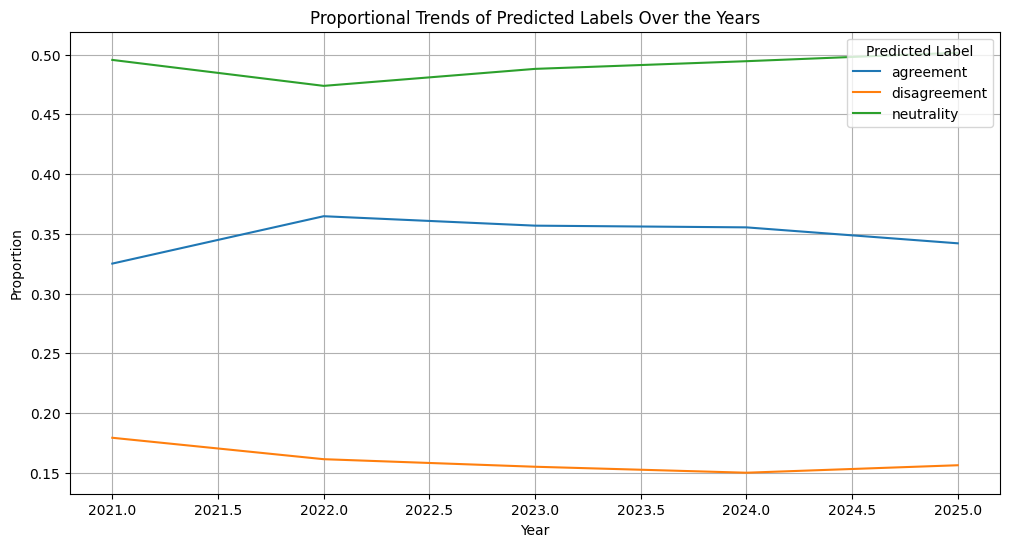

In [10]:
import matplotlib.pyplot as plt

# Step 1: Ensure 'Date' is in datetime format and extract the year
merged_df['Date'] = pd.to_datetime(merged_df['Date'])
merged_df['Year'] = merged_df['Date'].dt.year

# Step 2: Group by 'Year' and 'Predicted_Label' to count occurrences
label_trends = merged_df.groupby(['Year', 'model_label']).size().unstack(fill_value=0)

# Step 3: Normalize counts to proportions
total_counts_per_year = label_trends.sum(axis=1)
proportional_trends = label_trends.div(total_counts_per_year, axis=0)

# Step 4: Plot the proportional trends
plt.figure(figsize=(12, 6))
for label in proportional_trends.columns:
    plt.plot(proportional_trends.index, proportional_trends[label], label=label)

# Step 5: Add labels, title, legend, and grid
plt.title("Proportional Trends of Predicted Labels Over the Years")
plt.xlabel("Year")
plt.ylabel("Proportion")
plt.legend(title="Predicted Label")
plt.grid(True)

# Display the plot
plt.show()

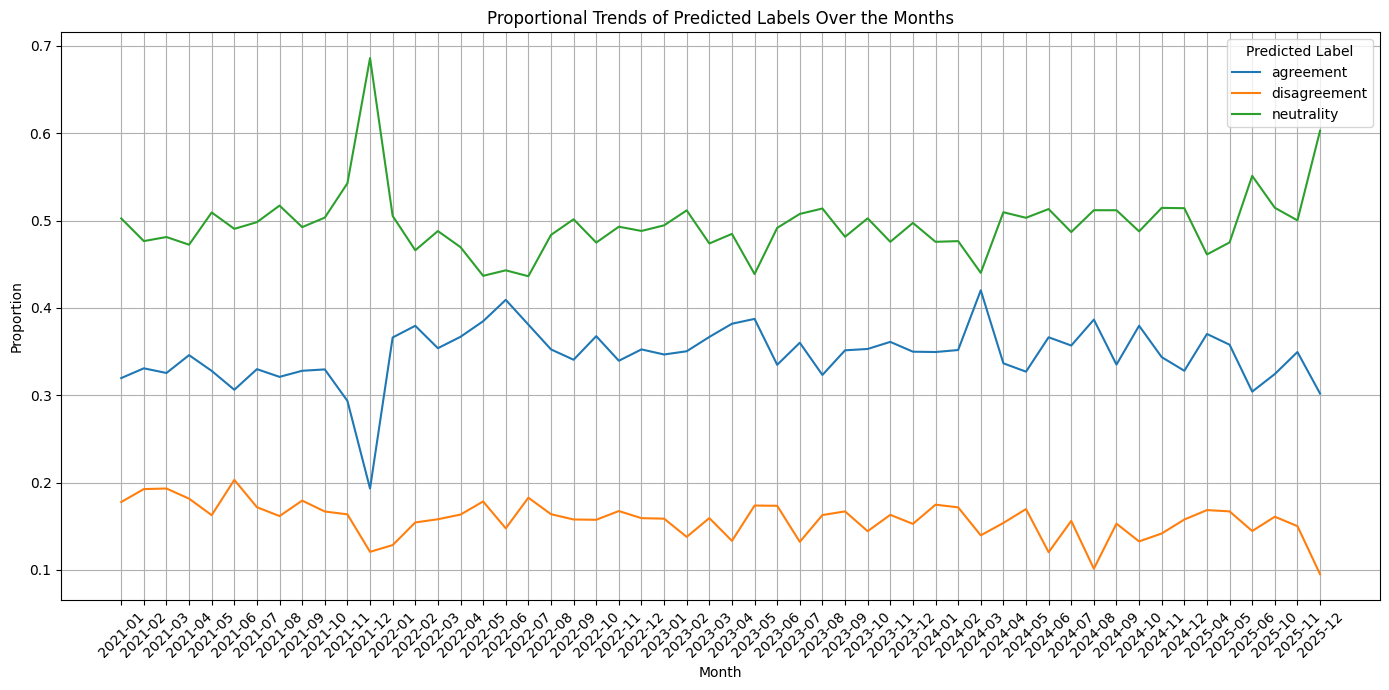

In [11]:
import matplotlib.pyplot as plt

# If your date column is strings like "YYYY-MM-DD", convert them…
final_df['date'] = pd.to_datetime(final_df['date'], format='%Y-%m-%d', errors='coerce')

# …and *then* you can pull out Month:
final_df['Month'] = final_df['date'].dt.to_period('M')

# Group by 'Month' and 'Predicted_Label' to count occurrences
label_trends_monthly = final_df.groupby(['Month', 'label']).size().unstack(fill_value=0)

# Normalize counts to proportions
total_counts_per_month = label_trends_monthly.sum(axis=1)
proportional_trends_monthly = label_trends_monthly.div(total_counts_per_month, axis=0)

# Plot the proportional trends
plt.figure(figsize=(14, 7))
for label in proportional_trends_monthly.columns:
    plt.plot(proportional_trends_monthly.index.astype(str), proportional_trends_monthly[label], label=label)

plt.title("Proportional Trends of Predicted Labels Over the Months")
plt.xlabel("Month")
plt.ylabel("Proportion")
plt.legend(title="Predicted Label")
plt.grid(True)
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.tight_layout()

# Display the plot
plt.show()

/tmp/ipykernel_55/3042478148.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df['Date'] = pd.to_datetime(merged_df['Date'])


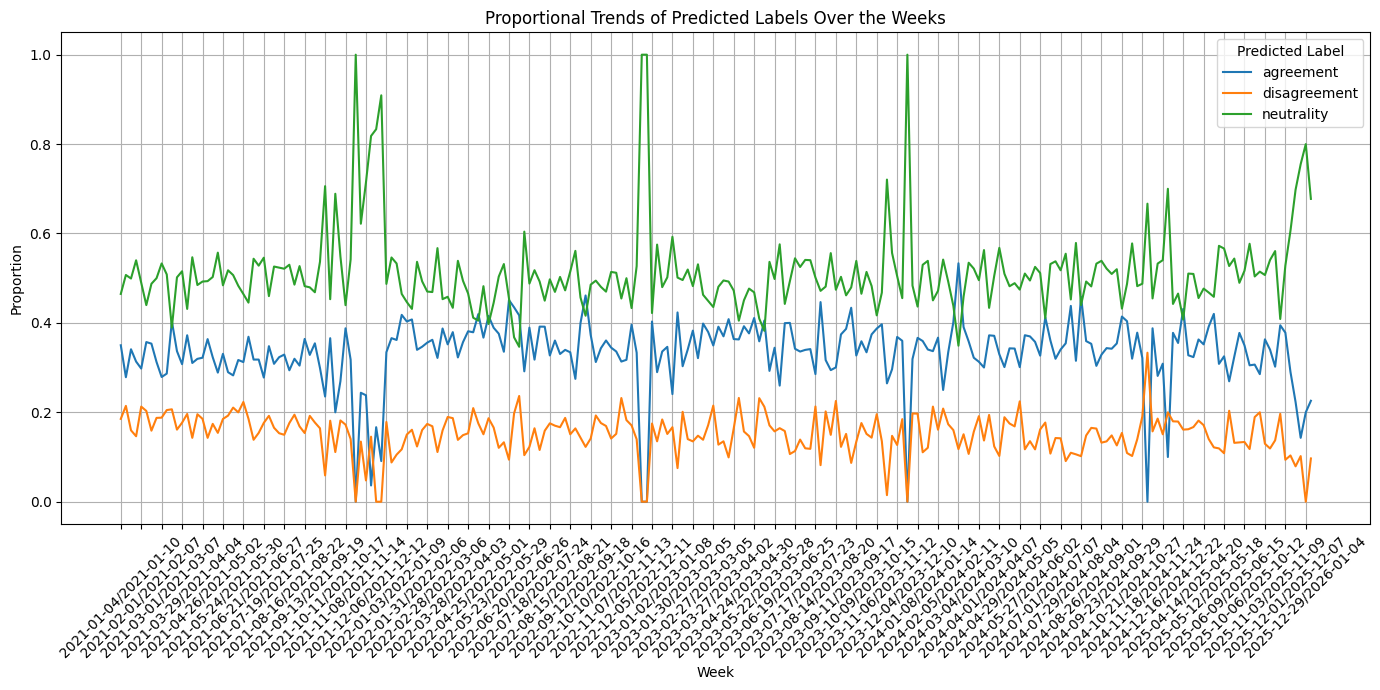

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Ensure 'Date' is in datetime format
merged_df['Date'] = pd.to_datetime(merged_df['Date'])

# Step 2: Define valid labels and filter out invalid ones
valid_labels = ['disagreement', 'neutrality', 'agreement']
merged_df = merged_df[merged_df['model_label'].isin(valid_labels)]

# Step 3: Extract the week period from the 'Date' column
merged_df['Week'] = merged_df['Date'].dt.to_period('W').apply(str)  # Week format as "YYYY-WW"

# Step 4: Group by 'Week' and 'Predicted_Label' to count occurrences
label_trends_weekly = merged_df.groupby(['Week', 'model_label']).size().unstack(fill_value=0)

# Step 5: Normalize counts to proportions
total_counts_per_week = label_trends_weekly.sum(axis=1)
proportional_trends_weekly = label_trends_weekly.div(total_counts_per_week, axis=0)

# Step 6: Plot proportional trends
plt.figure(figsize=(14, 7))
for label in proportional_trends_weekly.columns:
    plt.plot(proportional_trends_weekly.index, proportional_trends_weekly[label], label=label)

# Step 7: Add plot details
plt.title("Proportional Trends of Predicted Labels Over the Weeks")
plt.xlabel("Week")
plt.ylabel("Proportion")
plt.legend(title="Predicted Label")
plt.grid(True)

# Customize x-axis ticks to reduce overcrowding (e.g., one per 4 weeks)
xticks_to_display = proportional_trends_weekly.index[::4]
plt.xticks(xticks_to_display, rotation=45)

# Tight layout and display
plt.tight_layout()
plt.show()